<a href="https://colab.research.google.com/github/hariyanatchi-s/githubNMPROJECT/blob/main/NMproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# salea dataset
data={
    "Order_ID":[101,102,103,104,105,106,107,108,108],
    "Product":['Laptop','Mobile','Laptop','Tablet','Mobile',np.nan,'Tablet','Laptop','Laptop'],
    "Month":['Jan','Jan','Feb','Feb','Mar','Mar','Apr','Apr','Apr'],
    "Quantity":[2,5,3,4,6,2,5,3,3],
    "Price":[50000,20000,50000,150000,20000,30000,15000,50000,50000]

}
df=pd.DataFrame(data)
print(df)

   Order_ID Product Month  Quantity   Price
0       101  Laptop   Jan         2   50000
1       102  Mobile   Jan         5   20000
2       103  Laptop   Feb         3   50000
3       104  Tablet   Feb         4  150000
4       105  Mobile   Mar         6   20000
5       106     NaN   Mar         2   30000
6       107  Tablet   Apr         5   15000
7       108  Laptop   Apr         3   50000
8       108  Laptop   Apr         3   50000


In [3]:
print("original dataset")
print(df)
#remove duplicates
df=df.drop_duplicates()
print("dataset after removing duplicates")
print(df)


original dataset
   Order_ID Product Month  Quantity   Price
0       101  Laptop   Jan         2   50000
1       102  Mobile   Jan         5   20000
2       103  Laptop   Feb         3   50000
3       104  Tablet   Feb         4  150000
4       105  Mobile   Mar         6   20000
5       106     NaN   Mar         2   30000
6       107  Tablet   Apr         5   15000
7       108  Laptop   Apr         3   50000
8       108  Laptop   Apr         3   50000
dataset after removing duplicates
   Order_ID Product Month  Quantity   Price
0       101  Laptop   Jan         2   50000
1       102  Mobile   Jan         5   20000
2       103  Laptop   Feb         3   50000
3       104  Tablet   Feb         4  150000
4       105  Mobile   Mar         6   20000
5       106     NaN   Mar         2   30000
6       107  Tablet   Apr         5   15000
7       108  Laptop   Apr         3   50000


In [6]:
#fill missing product names
print("missing values:")
print(df.isnull().sum())

missing values:
Order_ID    0
Product     0
Month       0
Quantity    0
Price       0
dtype: int64


In [10]:
#Revenue calculation
df = df[df["Product"] != "unknown"].copy()
df["Revenue"]=df["Quantity"]*df["Price"]
print("\ncleaned Dataset")
print(df)


cleaned Dataset
   Order_ID Product Month  Quantity   Price  Revenue
0       101  Laptop   Jan         2   50000   100000
1       102  Mobile   Jan         5   20000   100000
2       103  Laptop   Feb         3   50000   150000
3       104  Tablet   Feb         4  150000   600000
4       105  Mobile   Mar         6   20000   120000
6       107  Tablet   Apr         5   15000    75000
7       108  Laptop   Apr         3   50000   150000


In [14]:
#top selling products
Product_sales=df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
print("\nTop selling products")
print(Product_sales)


Top selling products
Product
Tablet    675000
Laptop    400000
Mobile    220000
Name: Revenue, dtype: int64


In [15]:
#monthly sales
Monthly_sales=df.groupby('Month')['Revenue'].sum()
print("\nMonthly sales")
print(Monthly_sales)


Monthly sales
Month
Apr    225000
Feb    750000
Jan    200000
Mar    120000
Name: Revenue, dtype: int64


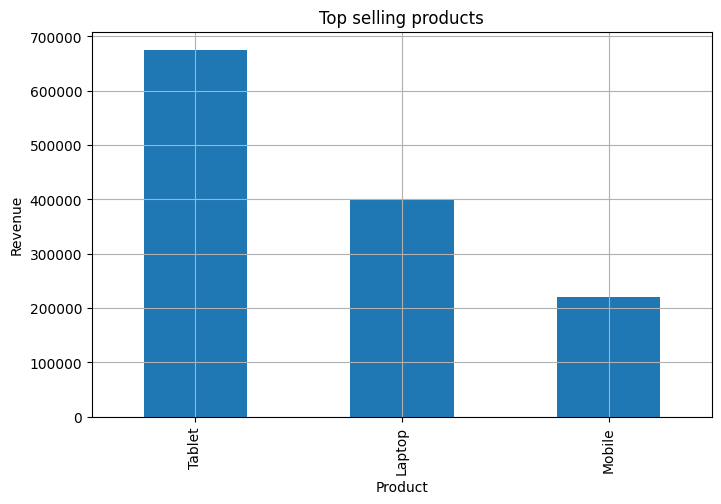

In [17]:
#visualization Bar
plt.figure(figsize=(8,5))
Product_sales.plot(kind='bar')
plt.title("Top selling products")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

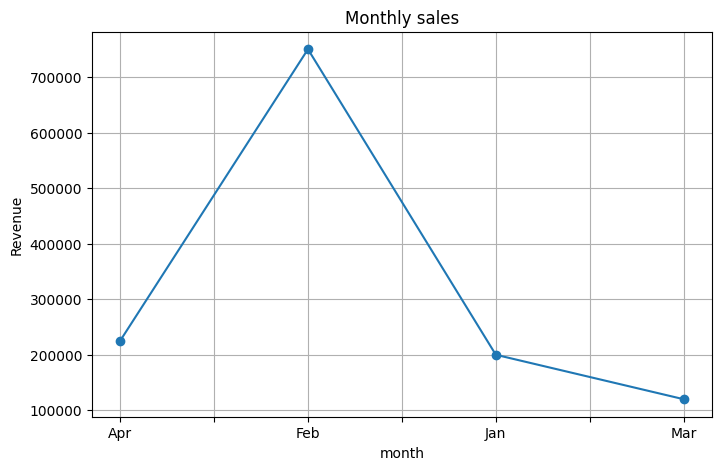

In [19]:
#visualization line
plt.figure(figsize=(8,5))
Monthly_sales.plot(kind='line',marker='o')
plt.title("Monthly sales")
plt.xlabel("month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()